<a href="https://colab.research.google.com/github/socooked/INST414/blob/main/Module6BryantMorris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Column names from NSL-KDD ARFF specification
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

df_train = pd.read_csv('KDDTrain+.txt', header=None, names=columns)
df_test = pd.read_csv('KDDTest+.txt', header=None, names=columns)

print(f"Training set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"\nLabel distribution (train):")
print(df_train['label'].value_counts().head(10))
df_train.head()

Training set: (13823, 43)
Test set: (13735, 43)

Label distribution (train):
label
normal         7348
neptune        4601
ipsweep         379
satan           367
portsweep       319
smurf           299
nmap            169
teardrop        103
warezclient      99
back             97
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491.0,0.0,0.0,0.0,0.0,0.0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20.0
1,0,udp,other,SF,146.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15.0
2,0,tcp,private,S0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19.0
3,0,tcp,http,SF,232.0,8153.0,0.0,0.0,0.0,0.0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21.0
4,0,tcp,http,SF,199.0,420.0,0.0,0.0,0.0,0.0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21.0


In [2]:
# Map specific attacks to their category
attack_map = {
    'normal': 'Normal',
    # DoS attacks
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS',
    'processtable': 'DoS', 'udpstorm': 'DoS',
    # Probe attacks
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    # R2L attacks
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'snmpgetattack': 'R2L', 'named': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L',
    'sendmail': 'R2L', 'httptunnel': 'R2L', 'worm': 'R2L', 'snmpguess': 'R2L',
    # U2R attacks
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'xterm': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
}

# Apply to both train and test
df_train['attack_category'] = df_train['label'].map(attack_map).fillna('Unknown')
df_test['attack_category'] = df_test['label'].map(attack_map).fillna('Unknown')

# Binary label: Normal (0) vs Attack (1)
df_train['is_attack'] = (df_train['attack_category'] != 'Normal').astype(int)
df_test['is_attack'] = (df_test['attack_category'] != 'Normal').astype(int)

print("=== Training Set ===")
print(f"\nAttack category distribution:")
print(df_train['attack_category'].value_counts())
print(f"\nBinary label distribution:")
print(df_train['is_attack'].value_counts())

print("\n=== Test Set ===")
print(f"\nAttack category distribution:")
print(df_test['attack_category'].value_counts())
print(f"\nBinary label distribution:")
print(df_test['is_attack'].value_counts())

=== Training Set ===

Attack category distribution:
attack_category
Normal     7348
DoS        5120
Probe      1234
R2L         115
U2R           5
Unknown       1
Name: count, dtype: int64

Binary label distribution:
is_attack
0    7348
1    6475
Name: count, dtype: int64

=== Test Set ===

Attack category distribution:
attack_category
Normal     5907
DoS        4571
R2L        1764
Probe      1447
U2R          45
Unknown       1
Name: count, dtype: int64

Binary label distribution:
is_attack
1    7828
0    5907
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder

# Drop the difficulty column (metadata, not a real feature)
df_train = df_train.drop('difficulty', axis=1)
df_test = df_test.drop('difficulty', axis=1)

# Encode the 3 categorical features: protocol_type, service, flag
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

# Fit on combined train+test to handle any values that appear only in test
combined_protocol = pd.concat([df_train['protocol_type'], df_test['protocol_type']])
combined_service = pd.concat([df_train['service'], df_test['service']])
combined_flag = pd.concat([df_train['flag'], df_test['flag']])

le_protocol.fit(combined_protocol)
le_service.fit(combined_service)
le_flag.fit(combined_flag)

df_train['protocol_type'] = le_protocol.transform(df_train['protocol_type'])
df_train['service'] = le_service.transform(df_train['service'])
df_train['flag'] = le_flag.transform(df_train['flag'])

df_test['protocol_type'] = le_protocol.transform(df_test['protocol_type'])
df_test['service'] = le_service.transform(df_test['service'])
df_test['flag'] = le_flag.transform(df_test['flag'])

# Define features (everything except label, attack_category, is_attack)
feature_cols = [c for c in df_train.columns if c not in ['label', 'attack_category', 'is_attack']]

X_train = df_train[feature_cols]
y_train = df_train['is_attack']
X_test = df_test[feature_cols]
y_test = df_test['is_attack']

print(f"Features: {len(feature_cols)}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"\nFirst 10 features: {feature_cols[:10]}")

Features: 41
X_train: (13823, 41), y_train: (13823,)
X_test: (13735, 41), y_test: (13735,)

First 10 features: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']


In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ---- RELOAD FROM SCRATCH ----
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

df_train = pd.read_csv('KDDTrain+.txt', header=None, names=columns)
df_test = pd.read_csv('KDDTest+.txt', header=None, names=columns)

# ---- ATTACK MAPPING ----
attack_map = {
    'normal': 'Normal',
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS',
    'processtable': 'DoS', 'udpstorm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'snmpgetattack': 'R2L', 'named': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L',
    'sendmail': 'R2L', 'httptunnel': 'R2L', 'worm': 'R2L', 'snmpguess': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'xterm': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
}

df_train['attack_category'] = df_train['label'].map(attack_map).fillna('Unknown')
df_test['attack_category'] = df_test['label'].map(attack_map).fillna('Unknown')
df_train['is_attack'] = (df_train['attack_category'] != 'Normal').astype(int)
df_test['is_attack'] = (df_test['attack_category'] != 'Normal').astype(int)

# ---- ENCODE CATEGORICALS ----
combined_protocol = pd.concat([df_train['protocol_type'], df_test['protocol_type']])
combined_service = pd.concat([df_train['service'], df_test['service']])
combined_flag = pd.concat([df_train['flag'], df_test['flag']])

le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()
le_protocol.fit(combined_protocol)
le_service.fit(combined_service)
le_flag.fit(combined_flag)

df_train['protocol_type'] = le_protocol.transform(df_train['protocol_type'])
df_train['service'] = le_service.transform(df_train['service'])
df_train['flag'] = le_flag.transform(df_train['flag'])
df_test['protocol_type'] = le_protocol.transform(df_test['protocol_type'])
df_test['service'] = le_service.transform(df_test['service'])
df_test['flag'] = le_flag.transform(df_test['flag'])

# ---- PREPARE FEATURES ----
feature_cols = [c for c in df_train.columns if c not in ['label', 'attack_category', 'is_attack', 'difficulty']]

X_train = df_train[feature_cols]
y_train = df_train['is_attack']
X_test = df_test[feature_cols]
y_test = df_test['is_attack']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (125973, 41), y_train: (125973,)
X_test: (22544, 41), y_test: (22544,)


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Model 1: Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}\n")
print(classification_report(y_test, dt_preds, target_names=['Normal', 'Attack']))

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\n=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}\n")
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Attack']))

=== Decision Tree ===
Accuracy: 0.7722

              precision    recall  f1-score   support

      Normal       0.66      0.97      0.79      9711
      Attack       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544


=== Random Forest ===
Accuracy: 0.7675

              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



# What the results mean:

- Accuracy (77%) — it got 77% of all predictions right overall
- Precision on Attack (97%) — when the model says "this is an attack," it's right 97% of the time. Very few false alarms
- Recall on Attack (62%) — but it only caught 62% of actual attacks. It missed 38% of them. That's dangerous — those are real attacks slipping through undetected
The tradeoff: the model is playing it safe. It would rather call something "normal" than risk a false alarm. For a security analyst, this is bad — a missed attack is worse than a false alarm

In [6]:
train_labels = set(df_train['label'].unique())
test_labels = set(df_test['label'].unique())

only_in_test = test_labels - train_labels
only_in_train = train_labels - test_labels

print(f"Attack types in training: {len(train_labels)}")
print(f"Attack types in test: {len(test_labels)}")
print(f"\nAttack types ONLY in test set (never seen during training):")
for label in sorted(only_in_test):
    count = df_test[df_test['label'] == label].shape[0]
    cat = df_test[df_test['label'] == label]['attack_category'].iloc[0]
    print(f"  {label}: {count} samples ({cat})")

print(f"\nHow many test samples are unseen attack types?")
unseen_mask = df_test['label'].isin(only_in_test)
print(f"  {unseen_mask.sum()} out of {len(df_test)} ({unseen_mask.sum()/len(df_test)*100:.1f}%)")

Attack types in training: 23
Attack types in test: 38

Attack types ONLY in test set (never seen during training):
  apache2: 737 samples (DoS)
  httptunnel: 133 samples (R2L)
  mailbomb: 293 samples (DoS)
  mscan: 996 samples (Probe)
  named: 17 samples (R2L)
  processtable: 685 samples (DoS)
  ps: 15 samples (U2R)
  saint: 319 samples (Probe)
  sendmail: 14 samples (R2L)
  snmpgetattack: 178 samples (R2L)
  snmpguess: 331 samples (R2L)
  sqlattack: 2 samples (U2R)
  udpstorm: 2 samples (DoS)
  worm: 2 samples (R2L)
  xlock: 9 samples (R2L)
  xsnoop: 4 samples (R2L)
  xterm: 13 samples (U2R)

How many test samples are unseen attack types?
  3750 out of 22544 (16.6%)


In [7]:
import numpy as np

# How does the model perform on each attack category?
print("=== Random Forest: Performance by Attack Category ===\n")
for cat in ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']:
    mask = df_test['attack_category'] == cat
    subset_true = y_test[mask]
    subset_pred = rf_preds[mask]
    correct = (subset_true == subset_pred).sum()
    total = mask.sum()
    acc = correct / total * 100
    print(f"{cat:8s}: {correct:5d} / {total:5d} correct ({acc:.1f}%)")

# How does it do on seen vs unseen attacks?
print("\n=== Seen vs Unseen Attack Types ===\n")
unseen = df_test['label'].isin(only_in_test)

seen_mask = (~unseen) & (df_test['attack_category'] != 'Normal')
unseen_mask = unseen

seen_correct = (rf_preds[seen_mask] == y_test[seen_mask]).sum()
unseen_correct = (rf_preds[unseen_mask] == y_test[unseen_mask]).sum()

print(f"Seen attacks:   {seen_correct} / {seen_mask.sum()} correct ({seen_correct/seen_mask.sum()*100:.1f}%)")
print(f"Unseen attacks: {unseen_correct} / {unseen_mask.sum()} correct ({unseen_correct/unseen_mask.sum()*100:.1f}%)")

=== Random Forest: Performance by Attack Category ===

Normal  :  9445 /  9711 correct (97.3%)
DoS     :  5809 /  7458 correct (77.9%)
Probe   :  1933 /  2421 correct (79.8%)
R2L     :   107 /  2887 correct (3.7%)
U2R     :     9 /    67 correct (13.4%)

=== Seen vs Unseen Attack Types ===

Seen attacks:   6917 / 9083 correct (76.2%)
Unseen attacks: 941 / 3750 correct (25.1%)


In [8]:
# Get all misclassified samples
wrong = df_test[rf_preds != y_test].copy()
wrong['predicted'] = rf_preds[rf_preds != y_test]
wrong['actual'] = y_test[rf_preds != y_test]

print(f"Total misclassified: {len(wrong)} out of {len(y_test)}\n")

# Pick 5 interesting errors from different categories
# 1. An R2L attack classified as normal
# 2. Another R2L attack classified as normal
# 3. A U2R attack classified as normal
# 4. A DoS attack classified as normal
# 5. A normal connection classified as attack (false positive)

samples = []

r2l_wrong = wrong[wrong['attack_category'] == 'R2L'].head(2)
u2r_wrong = wrong[wrong['attack_category'] == 'U2R'].head(1)
dos_wrong = wrong[wrong['attack_category'] == 'DoS'].head(1)
false_pos = wrong[(wrong['actual'] == 0) & (wrong['predicted'] == 1)].head(1)

error_samples = pd.concat([r2l_wrong, u2r_wrong, dos_wrong, false_pos])

for i, (idx, row) in enumerate(error_samples.iterrows(), 1):
    actual_label = 'Normal' if row['actual'] == 0 else 'Attack'
    pred_label = 'Normal' if row['predicted'] == 0 else 'Attack'
    print(f"--- Error #{i} ---")
    print(f"  Attack type: {row['label']} ({row['attack_category']})")
    print(f"  Actual: {actual_label} | Predicted: {pred_label}")
    print(f"  Duration: {row['duration']}, Protocol: {row['protocol_type']}")
    print(f"  Service: {row['service']}, Flag: {row['flag']}")
    print(f"  Src bytes: {row['src_bytes']}, Dst bytes: {row['dst_bytes']}")
    print(f"  Failed logins: {row['num_failed_logins']}, Logged in: {row['logged_in']}")
    print(f"  Count: {row['count']}, Srv count: {row['srv_count']}")
    print(f"  Serror rate: {row['serror_rate']}, Same srv rate: {row['same_srv_rate']}")
    print()

Total misclassified: 5241 out of 22544

--- Error #1 ---
  Attack type: guess_passwd (R2L)
  Actual: Attack | Predicted: Normal
  Duration: 0, Protocol: 1
  Service: 60, Flag: 9
  Src bytes: 129, Dst bytes: 174
  Failed logins: 1, Logged in: 0
  Count: 1, Srv count: 1
  Serror rate: 0.0, Same srv rate: 1.0

--- Error #2 ---
  Attack type: guess_passwd (R2L)
  Actual: Attack | Predicted: Normal
  Duration: 0, Protocol: 1
  Service: 19, Flag: 9
  Src bytes: 26, Dst bytes: 157
  Failed logins: 1, Logged in: 0
  Count: 1, Srv count: 1
  Serror rate: 0.0, Same srv rate: 1.0

--- Error #3 ---
  Attack type: buffer_overflow (U2R)
  Actual: Attack | Predicted: Normal
  Duration: 8, Protocol: 1
  Service: 19, Flag: 9
  Src bytes: 220, Dst bytes: 688
  Failed logins: 0, Logged in: 1
  Count: 1, Srv count: 1
  Serror rate: 0.0, Same srv rate: 1.0

--- Error #4 ---
  Attack type: apache2 (DoS)
  Actual: Attack | Predicted: Normal
  Duration: 805, Protocol: 1
  Service: 24, Flag: 4
  Src bytes: 769

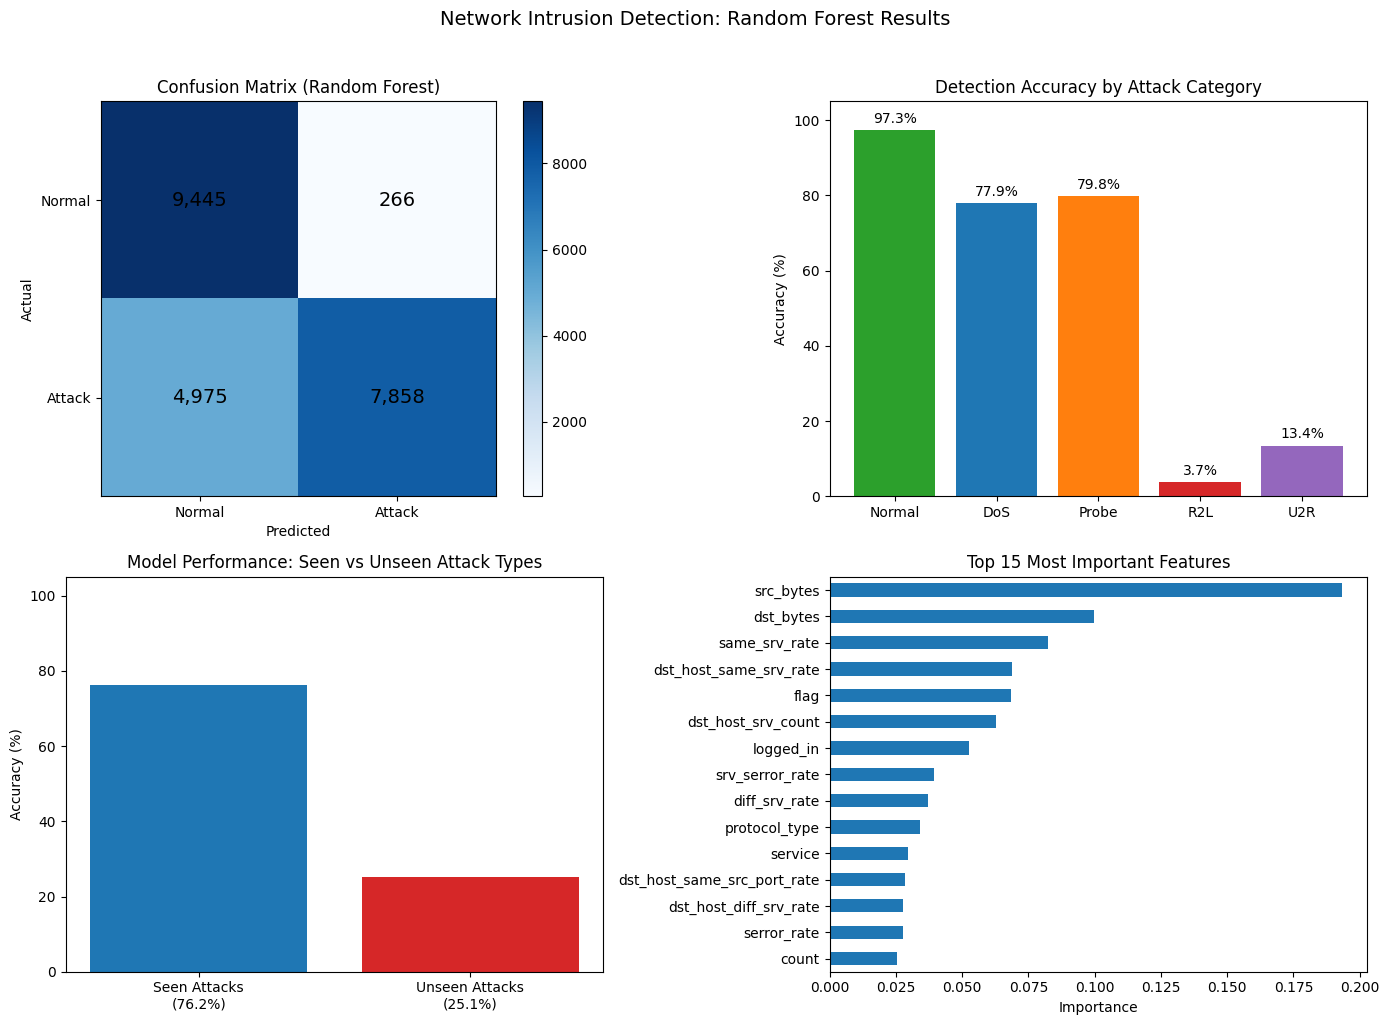

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
im = axes[0, 0].imshow(cm, cmap='Blues')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_yticks([0, 1])
axes[0, 0].set_xticklabels(['Normal', 'Attack'])
axes[0, 0].set_yticklabels(['Normal', 'Attack'])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Confusion Matrix (Random Forest)')
for i in range(2):
    for j in range(2):
        axes[0, 0].text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=14)
plt.colorbar(im, ax=axes[0, 0])

# 2. Accuracy by attack category
categories = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
accs = [97.3, 77.9, 79.8, 3.7, 13.4]
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']
axes[0, 1].bar(categories, accs, color=colors)
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Detection Accuracy by Attack Category')
axes[0, 1].set_ylim(0, 105)
for i, v in enumerate(accs):
    axes[0, 1].text(i, v + 2, f'{v}%', ha='center', fontsize=10)

# 3. Seen vs unseen attack performance
seen_unseen = ['Seen Attacks\n(76.2%)', 'Unseen Attacks\n(25.1%)']
seen_unseen_vals = [76.2, 25.1]
axes[1, 0].bar(seen_unseen, seen_unseen_vals, color=['#1f77b4', '#d62728'])
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Model Performance: Seen vs Unseen Attack Types')
axes[1, 0].set_ylim(0, 105)

# 4. Feature importance (top 15)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
feat_imp.tail(15).plot(kind='barh', ax=axes[1, 1], color='#1f77b4')
axes[1, 1].set_title('Top 15 Most Important Features')
axes[1, 1].set_xlabel('Importance')

plt.suptitle('Network Intrusion Detection: Random Forest Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()